#Metasurface generation with ADAM with feature reduction

Author: Ivan Ling
University of Southampton, 2025

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.optim as optim
import torch.nn.functional as F

#Generate a surface distribution based on 2D Fourier-Series

Here we are generating the height distribution using a generic 2D fourier series as the meta-surface height distribution should be symmetrical.

In [ ]:
def fourier_series_2d(x, y, coeffs, terms=5):
    z = torch.zeros_like(x)
    index = 0
    for m in range(1, terms + 1):
        for n in range(1, terms + 1):
            z += coeffs[index] * torch.sin(m * np.pi * x) * torch.sin(n * np.pi * y)
            index += 1
    return z

#Setting the target for Loss-Function calculation

Here we are using an arbitrary image for testing. However, in actual implementation, we would want to run a simulation and then pass the loss value back into the ADAM.

In [ ]:
# Load and preprocess the target image
def load_image(path, res=200):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
    img = cv2.resize(img, (res, res))  # Resize to 200x200
    img = img.astype(np.float32) / 255.0  # Normalize to [0,1]
    return torch.tensor(img, dtype=torch.float32)


#Sample code for generating fourier surface based on target image only. To be modified for metasurface generation

Here we run a sample pipeline where the target image is acquired and compared against the generated image. We will then use ADAM to modify the Fourier coefficients such that we will create an approximate image of the target.

In practice, we should be running a photonic simulation to get the final output pattern, and compare it to our target output pattern.

Currently, this code implements the following:

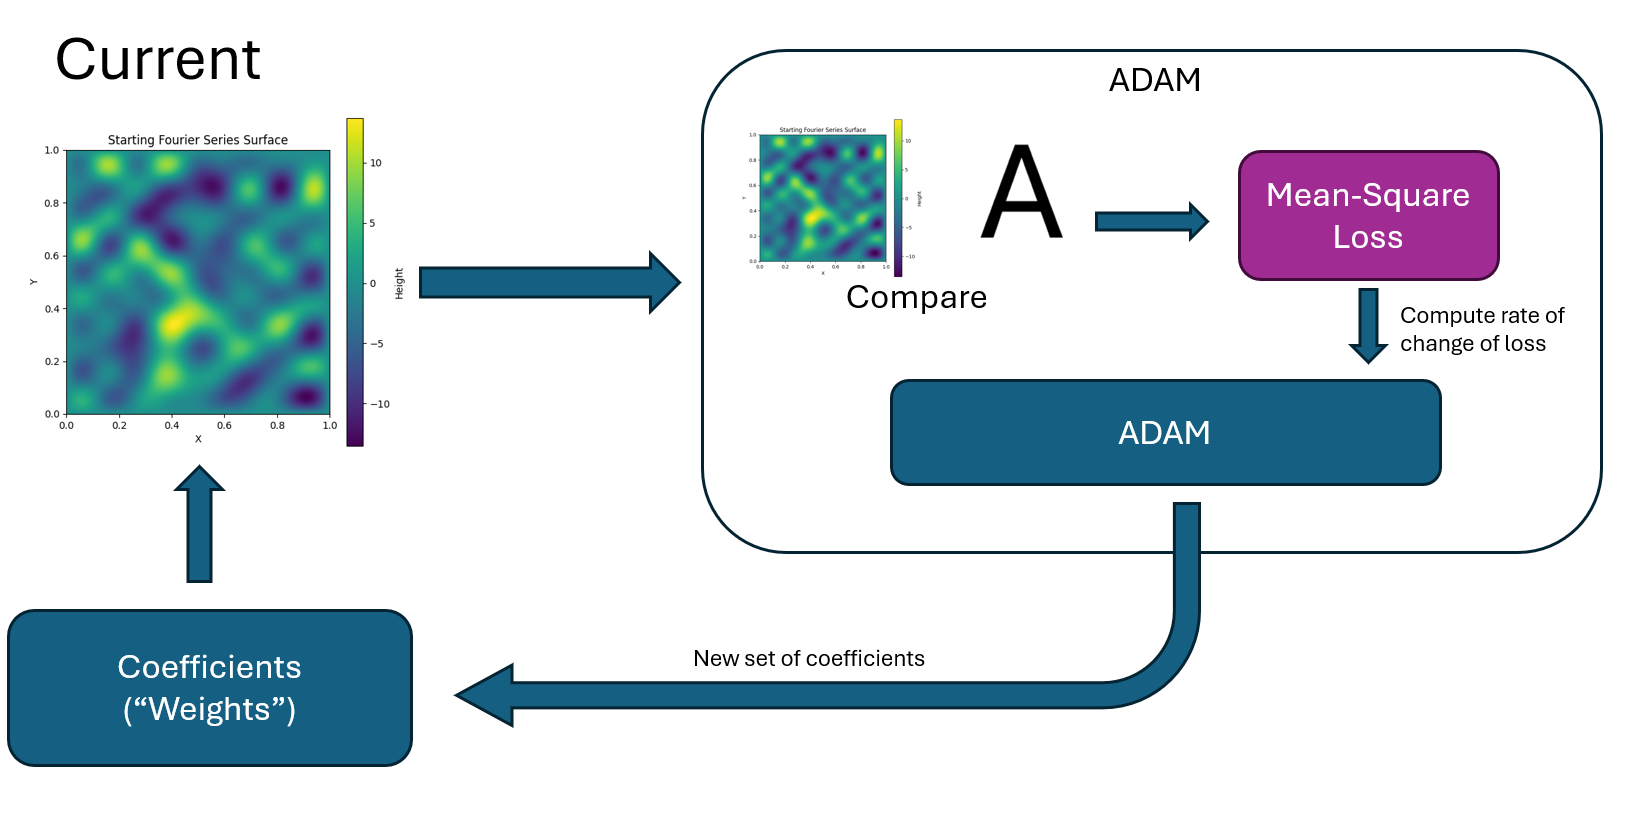

In [ ]:
#Hyper-parameters
res = 600  #Image resolution is resXres
terms = 20 #Number of Fourier coefficients
num_epochs = 100 #Number of iterations


In [ ]:
# Generate a generic random starting point
x = torch.linspace(0, 1, res)
y = torch.linspace(0, 1, res)
X, Y = torch.meshgrid(x, y, indexing='ij')

# Load target image
target_tensor = load_image('Target.png', res)

# Initialize coefficients as learnable parameters
num_coeffs = terms * terms
coeffs = torch.randn(num_coeffs, requires_grad=True) #Start from random numbers
Z = fourier_series_2d(X, Y, coeffs, terms).detach().numpy()

# Plot the result
plt.figure(figsize=(6, 6))
plt.imshow(Z, cmap='viridis', extent=[0, 1, 0, 1], origin='lower')
plt.colorbar(label='Height')
plt.title('Starting Fourier Series Surface')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [ ]:

# Set up ADAM optimizer
optimizer = optim.Adam([coeffs], lr=0.1)
loss_array = []

# Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Compute Fourier approximation
    approx_tensor = fourier_series_2d(X, Y, coeffs, terms)

    # Compute loss (Mean Squared Error)
    loss = torch.mean((approx_tensor - target_tensor) ** 2)
    loss_array.append(loss.item())
    ## TODO: Need to add the photonic simulation here

    # Backpropagation
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f'Epoch {epoch}/{num_epochs}, Loss: {loss.item()}')


In [ ]:
plt.plot(range(0, num_epochs, 1), loss_array)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.show()


In [ ]:
# Compute the final Fourier surface
Z = fourier_series_2d(X, Y, coeffs, terms).detach().numpy()

# Plot the result
plt.figure(figsize=(6, 6))
plt.imshow(Z, cmap='viridis', extent=[0, 1, 0, 1], origin='lower')
plt.colorbar(label='Height')
plt.title('Optimized 2D Fourier Series Surface')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [ ]:
coeffs

In [ ]:
# Comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Target image
ax[0].imshow(np.rot90(target_tensor.numpy(), 2), cmap='gray', extent=[0, 1, 0, 1], origin='lower')
ax[0].set_title('Target Image')
ax[0].axis('off')

# Fourier-generated image
ax[1].imshow(np.rot90(Z, 2), cmap='gray', extent=[0, 1, 0, 1], origin='lower')
ax[1].set_title('Fourier Approximation (Rotated 180°)')
ax[1].axis('off')

plt.show()


In [ ]:
#Generate the Mask with overlay

num_circles = 50
rad_scale = 0.004
rad_min = 0.002

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(Z, cmap='gray', extent=[0, 1, 0, 1], origin='lower')
ax.set_title('Fourier Image with Circles')

step_x = 1 / num_circles
step_y = 1 / num_circles

for i in range(num_circles):
    for j in range(num_circles):
        x = i * step_x
        y = j * step_y
        intensity = Z[int(j * (res - 1) / num_circles), int(i * (res - 1) / num_circles)]
        radius = rad_min + rad_scale * intensity  # Scale radius by intensity
        circle = plt.Circle((x, y), radius, color='red', fill=False)
        ax.add_patch(circle)

plt.show()


In [ ]:
#Generate the Mask image

fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

step_x = 1 / num_circles
step_y = 1 / num_circles

for i in range(num_circles):
    for j in range(num_circles):
        x = (i-0.5) * step_x
        y = (j-0.5) * step_y
        intensity = Z[int(j * (res - 1) / num_circles), int(i * (res - 1) / num_circles)]
        radius = rad_min + rad_scale * intensity  # Scale radius by intensity
        circle = plt.Circle((x, y), radius, color='black', fill='black')
        ax.add_patch(circle)

plt.show()


#Target

Going forward, our target is to be able to generate metasurfaces for arbitrary lightfield from the given input. Within literature, there are already other methodologies, but we will try to compare our methods to them.

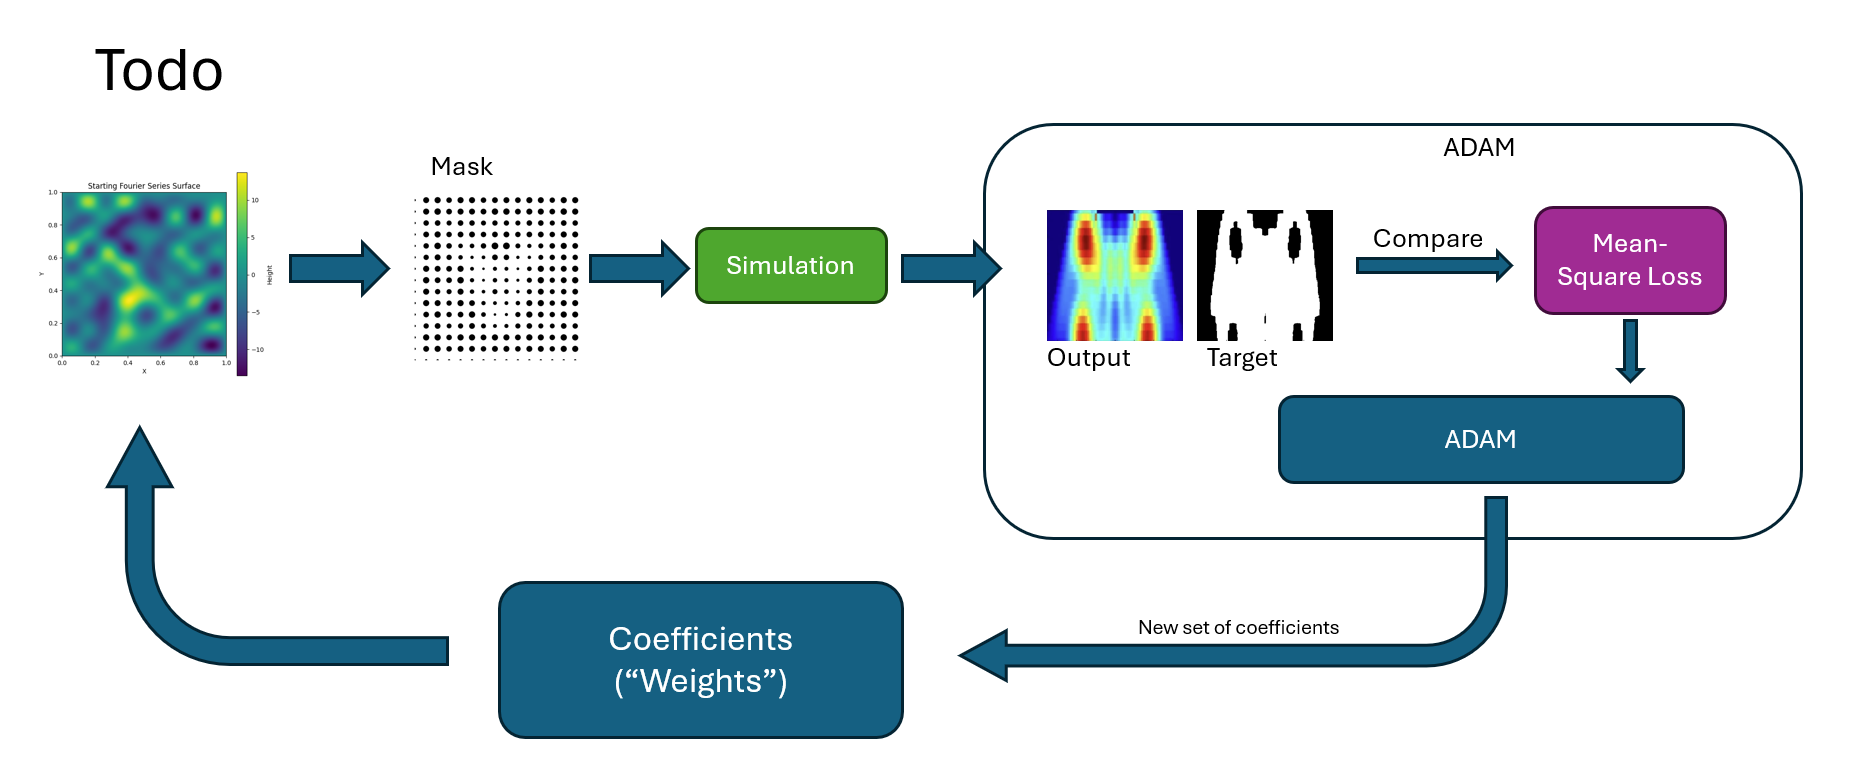

# Ignore codes below...

In [ ]:
def generate_mask(coeffs, num_circles, res, rad_min, rad_scale, X, Y, terms):
    device = coeffs.device
    Z = fourier_series_2d(X, Y, coeffs, terms)

    mask = torch.zeros((res, res), device=device, dtype=torch.float32)
    step_x = res / num_circles
    step_y = res / num_circles

    for i in range(num_circles):
        for j in range(num_circles):
            x = int((i + 0.5) * step_x)
            y = int((j + 0.5) * step_y)

            intensity = Z[min(int(j * (Z.shape[0] - 1) / num_circles), Z.shape[0] - 1),
                          min(int(i * (Z.shape[1] - 1) / num_circles), Z.shape[1] - 1)]
            radius = rad_min + rad_scale * intensity

            yy, xx = torch.meshgrid(torch.arange(res, device=device), torch.arange(res, device=device), indexing='ij')
            dist = torch.sqrt((xx - x) ** 2 + (yy - y) ** 2)
            mask += (dist <= radius).float()

    mask = mask.clamp(0, 1)
    return mask


In [ ]:
plt.imshow(generate_mask(Z, 50, 0.004, 0.002)) #Test function

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

step_x = 1 / num_circles
step_y = 1 / num_circles

for i in range(num_circles):
    for j in range(num_circles):
        x = (i-0.5) * step_x
        y = (j-0.5) * step_y
        intensity = Z[int(j * (res - 1) / num_circles), int(i * (res - 1) / num_circles)]
        radius = rad_min + rad_scale * intensity  # Scale radius by intensity
        circle = plt.Circle((x, y), radius, color='black', fill='black')
        ax.add_patch(circle)

# Save the plot to a temporary file
plt.savefig('temp_image.png', bbox_inches='tight', pad_inches=0)
plt.close(fig) # Close the figure to free up resources

mask_image = cv2.imread('temp_image.png', cv2.IMREAD_GRAYSCALE)


In [ ]:
def generate_shadow(mask, blur_size=5, erosion_size=3, final_blur_size=7):
    if mask is None:
        raise ValueError("Error: mask is None. Please provide a valid tensor.")

    device = mask.device
    mask = mask.float()

    blur_kernel_size = blur_size | 1
    blur_kernel = torch.ones((1, 1, blur_kernel_size, blur_kernel_size), device=device) / (blur_kernel_size ** 2)
    shadow = F.conv2d(mask.unsqueeze(0).unsqueeze(0), blur_kernel, padding=blur_kernel_size//2).squeeze()

    shadow = (shadow > 0.2).float()  # Threshold

    erosion_kernel_size = erosion_size | 1
    shadow = -F.max_pool2d(-shadow.unsqueeze(0).unsqueeze(0), kernel_size=erosion_kernel_size, stride=1, padding=erosion_kernel_size//2).squeeze()

    final_blur_kernel_size = final_blur_size | 1
    final_blur_kernel = torch.ones((1, 1, final_blur_kernel_size, final_blur_kernel_size), device=device) / (final_blur_kernel_size ** 2)
    shadow = F.conv2d(shadow.unsqueeze(0).unsqueeze(0), final_blur_kernel, padding=final_blur_kernel_size//2).squeeze()

    return shadow


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.optim as optim
import torch.nn.functional as F

def fourier_series_2d(x, y, coeffs, terms=5):
    z = torch.zeros_like(x)
    index = 0
    for m in range(1, terms + 1):
        for n in range(1, terms + 1):
            z += coeffs[index] * torch.sin(m * np.pi * x) * torch.sin(n * np.pi * y)
            index += 1
    return z

def load_image(path, res=200):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (res, res))
    img = img.astype(np.float32) / 255.0
    return torch.tensor(img, dtype=torch.float32)

def generate_mask(X, Y, coeffs, num_circles, res, rad_min, rad_scale, terms=10):
    device = coeffs.device
    Z = fourier_series_2d(X, Y, coeffs, terms)

    step = res / num_circles
    # Create 1D center coordinates
    x_centers_1d = (torch.arange(num_circles, device=device).float() + 0.5) * step
    y_centers_1d = (torch.arange(num_circles, device=device).float() + 0.5) * step

    # Create 2D grid of centers using meshgrid
    x_centers, y_centers = torch.meshgrid(x_centers_1d, y_centers_1d, indexing='ij')

    # Convert to normalized coordinates for grid_sample
    x_norm = (x_centers / (res - 1)) * 2 - 1
    y_norm = (y_centers / (res - 1)) * 2 - 1
    grid = torch.stack((x_norm.unsqueeze(-1), y_norm.unsqueeze(-1)), dim=-1).unsqueeze(0)

    # Sample intensities from Z
    Z_batch = Z.unsqueeze(0).unsqueeze(0)
    intensities = F.grid_sample(Z_batch, grid, mode='bilinear', align_corners=True).squeeze()

    # Calculate radii
    radii = rad_min + rad_scale * intensities

    # Create coordinate grid for the full image
    yy, xx = torch.meshgrid(torch.arange(res, device=device),
                           torch.arange(res, device=device), indexing='ij')
    xx = xx.float().unsqueeze(-1).unsqueeze(-1)  # [res, res, 1, 1]
    yy = yy.float().unsqueeze(-1).unsqueeze(-1)  # [res, res, 1, 1]

    # Prepare centers and radii for broadcasting
    x_centers = x_centers.reshape(1, 1, num_circles, num_circles)
    y_centers = y_centers.reshape(1, 1, num_circles, num_circles)
    radii = radii.reshape(1, 1, num_circles, num_circles)

    # Calculate distances
    dist_sq = (xx - x_centers)**2 + (yy - y_centers)**2

    # Create mask using broadcasting
    mask = (dist_sq <= radii**2).any(dim=(-1, -2))

    return mask.float()

def generate_shadow(mask, blur_size=5, erosion_size=3, final_blur_size=7):
    device = mask.device
    mask = mask.float()

    def gaussian_kernel(size, sigma):
        coords = torch.arange(size, device=device).float() - size//2
        g = torch.exp(-coords**2 / (2 * sigma**2))
        g /= g.sum()
        return g.outer(g).unsqueeze(0).unsqueeze(0)

    # Initial Gaussian blur
    blur_kernel_size = blur_size | 1
    sigma_blur = blur_kernel_size / 6
    blur_kernel = gaussian_kernel(blur_kernel_size, sigma_blur)
    shadow = F.conv2d(mask.unsqueeze(0).unsqueeze(0), blur_kernel, padding=blur_kernel_size//2).squeeze()

    # Thresholding
    shadow = (shadow > 0.2).float()

    # Erosion
    erosion_kernel_size = erosion_size | 1
    shadow = -F.max_pool2d(-shadow.unsqueeze(0).unsqueeze(0), kernel_size=erosion_kernel_size,
                          stride=1, padding=erosion_kernel_size//2).squeeze()

    # Final Gaussian blur
    final_blur_kernel_size = final_blur_size | 1
    sigma_final = final_blur_kernel_size / 6
    final_blur_kernel = gaussian_kernel(final_blur_kernel_size, sigma_final)
    shadow = F.conv2d(shadow.unsqueeze(0).unsqueeze(0), final_blur_kernel,
                     padding=final_blur_kernel_size//2).squeeze()

    return shadow

# Hyperparameters
res = 100
terms = 10
num_epochs = 500
num_circles = 50
rad_min = 0.004
rad_scale = 0.002

# Initialize coefficients
num_coeffs = terms * terms
coeffs = torch.randn(num_coeffs, requires_grad=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
coeffs = coeffs.to(device)

# Create grid
x = torch.linspace(0, 1, res, device=device)
y = torch.linspace(0, 1, res, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')

# Load and prepare target
target_tensor = load_image('Target.png', res).to(device)

# Optimizer
optimizer = optim.Adam([coeffs], lr=0.1)
loss_history = []

# Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()

    approx_mask = generate_mask(X, Y, coeffs, num_circles, res, rad_min, rad_scale)
    approx_shadow = generate_shadow(approx_mask)

    loss = F.mse_loss(approx_shadow, target_tensor)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if epoch % 10 == 0:
        print(f'Epoch {epoch}/{num_epochs}, Loss: {loss.item():.4f}')

# Plot results
plt.plot(loss_history)
plt.title('Training Loss')
plt.show()

with torch.no_grad():
    final_mask = generate_mask(X, Y, coeffs, num_circles, res, rad_min, rad_scale)
    final_shadow = generate_shadow(final_mask)

plt.imshow(final_shadow.cpu().numpy(), cmap='gray')
plt.title('Generated Shadow')
plt.show()

In [ ]:
# Compute the final Fourier surface
Z = fourier_series_2d(X, Y, coeffs, terms).detach().numpy()
